In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

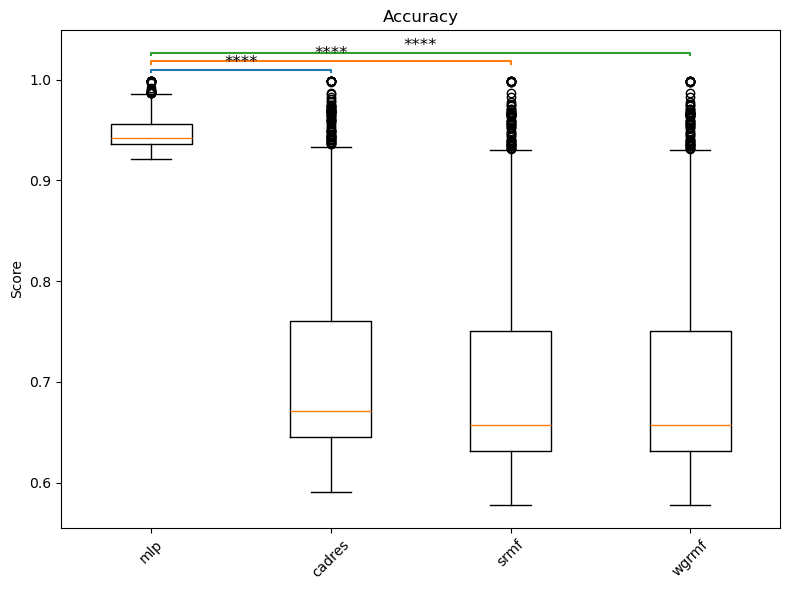

In [2]:
# Read data
df = pd.read_csv('accuracy_per_drug.csv')

# Reorder
data = [df["mlp"], df["cadres"], df["srmf"], df["wgrmf"]]
labels = ["mlp", "cadres", "srmf", "wgrmf"]

# Create plot
plt.figure(figsize=(8,6))
plt.boxplot(data, labels=labels)
plt.ylabel("Score")
plt.title("Accuracy")
plt.xticks(rotation=45)

# Function: p-value to stars
def p_to_star(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# Wilcoxon tests: mlp vs others
y_max = max([d.max() for d in data])
y_step = 0.02 * (y_max - min([d.min() for d in data]))

comparisons = [(0,1), (0,2), (0,3)]  # mlp vs others

for i, (a, b) in enumerate(comparisons):
    # drop NaNs pairwise
    x = data[a].dropna()
    y = data[b].dropna()
    
    # ensure same length (wilcoxon requires paired samples)
    min_len = min(len(x), len(y))
    x = x.iloc[:min_len]
    y = y.iloc[:min_len]

    stat, p = wilcoxon(x, y)
    stars = p_to_star(p)

    y_line = y_max + (i+1)*y_step

    # draw bracket
    plt.plot([a+1, a+1, b+1, b+1],
             [y_line, y_line+y_step/4, y_line+y_step/4, y_line],
             lw=1.5)

    # add stars
    plt.text((a+b)/2 + 1, y_line+y_step/4,
             stars, ha='center', va='bottom', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

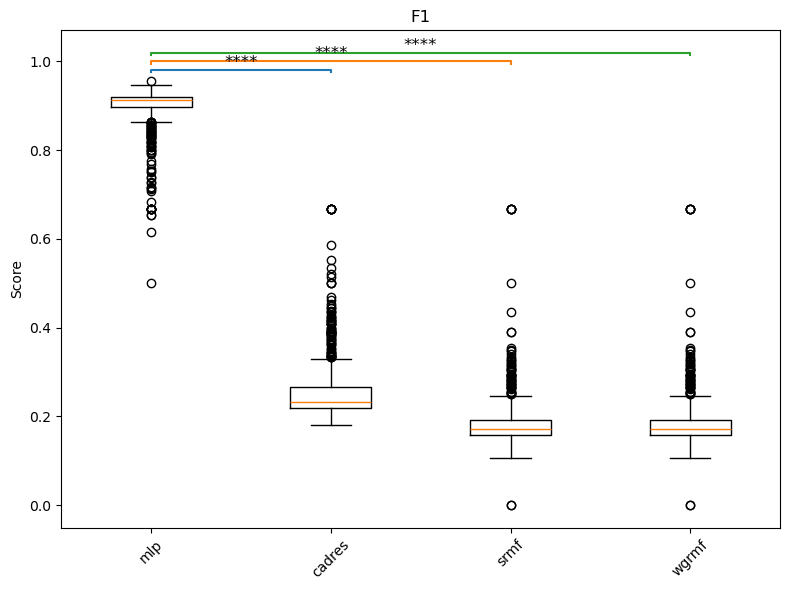

In [3]:
# Read data
df = pd.read_csv('f1_per_drug.csv')

# Reorder
data = [df["mlp"], df["cadres"], df["srmf"], df["wgrmf"]]
labels = ["mlp", "cadres", "srmf", "wgrmf"]

# Create plot
plt.figure(figsize=(8,6))
plt.boxplot(data, labels=labels)
plt.ylabel("Score")
plt.title("F1")
plt.xticks(rotation=45)

# Function: p-value to stars
def p_to_star(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# Wilcoxon tests: mlp vs others
y_max = max([d.max() for d in data])
y_step = 0.02 * (y_max - min([d.min() for d in data]))

comparisons = [(0,1), (0,2), (0,3)]  # mlp vs others

for i, (a, b) in enumerate(comparisons):
    # drop NaNs pairwise
    x = data[a].dropna()
    y = data[b].dropna()
    
    # ensure same length (wilcoxon requires paired samples)
    min_len = min(len(x), len(y))
    x = x.iloc[:min_len]
    y = y.iloc[:min_len]

    stat, p = wilcoxon(x, y)
    stars = p_to_star(p)

    y_line = y_max + (i+1)*y_step

    # draw bracket
    plt.plot([a+1, a+1, b+1, b+1],
             [y_line, y_line+y_step/4, y_line+y_step/4, y_line],
             lw=1.5)

    # add stars
    plt.text((a+b)/2 + 1, y_line+y_step/4,
             stars, ha='center', va='bottom', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()